In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

In [22]:
import pandas as pd # 파일입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.model_selection import train_test_split # 훈련셋과 시험셋 분리 함수
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential, save_model, load_model
# 과적합을 줄이기 위한 방법 : dropout, 배치정규화, L2정규화
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization # dropout은 과적합을 줄이기 위한 방법
from tensorflow.keras.regularizers import l2
# 데이터 불균형 극복 5.5 : 4.5 => 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt # 모델 학습과정 살펴보기
from sklearn.metrics import confusion_matrix # 혼동행렬

# 이진분류(로지스틱 회귀분석)
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프레임 -> ?처리(결측치로 전환하여 결측치 처리) -> X, y분리
        -> X변수의 scale조정 -> train_test_split()을 이용하여 학습셋과 테스트셋을 분리
- 2. 모델 생성(입력13, 타겟1) & 학습과정설정 & 학습
- 3. 모델 평가(그래프, 평가, 혼동행렬=교차표)
- 4. 모델 사용

## 1. 데이터셋 생성&전처리

In [23]:
df = pd.read_excel('data/heart-disease.xlsx', )
df.head()

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [25]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [26]:
df.isin( ['?'] ).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [27]:
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [28]:
# 방법1 : ?가 있는 행을 삭제
drop_idx = df[ (df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ].index # 삭제할 행
df = df.drop(drop_idx)

In [29]:
# 방법2) ?를 결측치로 대체 -> 결측치 삭제
df = df.replace('?', np.nan)
df[ (df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [30]:
# 결측치가 포함된 데이터 추출
df[ df.isna() | df['ca'].isna() | df['hsl'].isna() ]
df[ df.isna().any(axis=1) ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [31]:
# 결측치 처리 : 삭제(dropna) cf. fillna() apply()
df.dropna(how='any', inplace=True) # 결측치가 한열이라도 있으면 삭제
df[ df.isna().any(axis=1) ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [32]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [33]:
df.shape

(296, 14)

In [34]:
# 타겟변수 분포가 균형적인지
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [35]:
# x, y분리 -> x변수의 scale조정
X = df.iloc[:, :-1].values # 맨마지막 열을 제외한 부분을 numpy배열
y = df.iloc[:, -1:].to_numpy() # 2차원 numpy 배열
X.shape, y.shape

((296, 13), (296, 1))

In [36]:
# X변수의 scale조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
print('원 데이터 :', X[0])
print('스케일 조정 데이터 :', scaled_X[0])

원 데이터 : [63 1 1 145 233 1 2 150 0 2.3 3 0 6]
스케일 조정 데이터 : [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [38]:
# scaled_X와 y를 학습데이터셋:테스트셋 = 8:2
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                    y,
                                    #train_size=0.8,
                                    test_size=0.2,
                                    random_state=7,
                                    stratify=y) # 층화추출

In [39]:
# 심장병 음성/양성 비율(y, y_train, y_test)
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


In [40]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

## 2. 모델생성 & 학습과정 설정 & 학습
- 모델 : 13 -> 32 -> 16 -> 8 -> 1
- 학습과정을 시각화한 그래프를 보고 과적합 줄이기 
- 과적합 줄이기 위한 방법
    * dropout : 학습할 때마다 일부 뉴런을 랜덤하게 끄기. 특정 뉴런 조합에 과하게 의존하는 것을 막아줌.
    * BatchNormalization(배치 정규화) : 각 층의 출력을 정규화해서 더 안정적이고 빠르게 수렴하도록 도와줌.
    * L2 정규화(규제) : 가중치가 너무 커지지 않게 학습과정에서 미리 누름. 가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜. 
    * 규제를 강하게(0.01) / 규제 중간(0.001) / 규제 약하게(0.0001)

In [73]:
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화(최적화)
model.add(Dropout(0.4))               # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# Dense층 뒤에 배치정규화층에서의 파라미터 : Dense층(32) 출력개수 * 4
# ggamma(스케일)                      - 32 (학습됨)
# beta(이동)                               - 32 (학습됨)
# moving_mean(이동평균)       - 32 (학습안됨)
# moving_variance(이동분산) - 32 (학습안됨)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_4 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 32)                0         
                                                                 
 dense_13 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_5 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 16)                0

In [81]:
# 학습과정 설정
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.optimizers import Adam
model.compile(
    loss='binary_crossentropy', 
    optimizer=Adam(),    #  optimizer='adam',
    metrics=['accuracy', # Accuracy(name='accuracy');
                    Recall(name='recall'),  # 재현율(실제값 중심=1을 얼마나 잘 예측했는지)
                    Precision(name='precision') ] # 정밀도(예측값 중심=1이라고 예측한 것 중 얼마나 1인지)
)

In [74]:
# 클래스(0/1) 가중치 계산 (55:45 정도의 비율 => 50:50)
y_train_flat = y_train.flatten() # y_train.reshape(-1)
class_weight = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y = y_train_flat
)
print('class_weight :', class_weight)
class_weight_dict = dict(enumerate(class_weight))
print('학습시 가중치 조정값 : ', class_weight_dict)
# y_train의 빈도수(0은?개, 1은?개)
values, counts = np.unique(y_train_flat, return_counts=True)
print('빈도수 :', dict(zip(values, counts)))
print(counts[0]*class_weight_dict[0], counts[1]*class_weight_dict[1])
# 빈도 분포
ratios = counts / counts.sum()
print(ratios[0]*class_weight_dict[0], ratios[1]*class_weight_dict[1])

class_weight : [0.921875   1.09259259]
학습시 가중치 조정값 :  {0: 0.921875, 1: 1.0925925925925926}
빈도수 : {0: 128, 1: 108}
118.0 118.0
0.5 0.5


In [75]:
# callback 설정
# ReduceLROnplateau : 성능이 정체되면 학습률(Learing_rate)을 낮춰서 세밀하게 탐색
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   # 학습률을 원학습률의 절반으로
    patience=7, # 7번 연속 개선이 없으면
    min_lr=1e-6 # 학습률의 최소값 10의 -6승 이하로는 안 내려가게 설정
)

In [82]:
# 학습
hist = model.fit(
    X_train, y_train, # 학습데이터
    epochs=200, # 학습횟수
#    batch_size=200,
    validation_split=0.2, # 학습데이터에서 20%를 검증데이터로 사용
    class_weight=class_weight_dict, # Loss 계산시 얼마나 더 중요하게 취급될지의 가중치
    callbacks=[reduce_lr],
    verbose=2
)

Epoch 1/200
6/6 - 2s - loss: 0.8576 - accuracy: 0.5160 - recall: 0.4138 - precision: 0.4737 - val_loss: 0.6986 - val_accuracy: 0.5625 - val_recall: 0.8095 - val_precision: 0.5000 - lr: 0.0010 - 2s/epoch - 364ms/step
Epoch 2/200
6/6 - 0s - loss: 0.7639 - accuracy: 0.6011 - recall: 0.5287 - precision: 0.5750 - val_loss: 0.6906 - val_accuracy: 0.7083 - val_recall: 0.8095 - val_precision: 0.6296 - lr: 0.0010 - 44ms/epoch - 7ms/step
Epoch 3/200
6/6 - 0s - loss: 0.7731 - accuracy: 0.5266 - recall: 0.3908 - precision: 0.4857 - val_loss: 0.6822 - val_accuracy: 0.7292 - val_recall: 0.7619 - val_precision: 0.6667 - lr: 0.0010 - 41ms/epoch - 7ms/step
Epoch 4/200
6/6 - 0s - loss: 0.7865 - accuracy: 0.5691 - recall: 0.5287 - precision: 0.5349 - val_loss: 0.6745 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - lr: 0.0010 - 47ms/epoch - 8ms/step
Epoch 5/200
6/6 - 0s - loss: 0.7339 - accuracy: 0.6064 - recall: 0.5402 - precision: 0.5802 - val_loss: 0.6673 - val_accuracy: 0.7708 - 

Epoch 39/200
6/6 - 0s - loss: 0.5182 - accuracy: 0.7713 - recall: 0.7126 - precision: 0.7750 - val_loss: 0.4804 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 49ms/epoch - 8ms/step
Epoch 40/200
6/6 - 0s - loss: 0.5038 - accuracy: 0.7713 - recall: 0.7241 - precision: 0.7683 - val_loss: 0.4767 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 51ms/epoch - 8ms/step
Epoch 41/200
6/6 - 0s - loss: 0.5917 - accuracy: 0.6968 - recall: 0.6322 - precision: 0.6875 - val_loss: 0.4735 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 59ms/epoch - 10ms/step
Epoch 42/200
6/6 - 0s - loss: 0.5086 - accuracy: 0.7926 - recall: 0.7356 - precision: 0.8000 - val_loss: 0.4719 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - lr: 0.0010 - 43ms/epoch - 7ms/step
Epoch 43/200
6/6 - 0s - loss: 0.5113 - accuracy: 0.7553 - recall: 0.7011 - precision: 0.7531 - val_loss: 0.4692 - val_accuracy: 0.7

Epoch 77/200
6/6 - 0s - loss: 0.4566 - accuracy: 0.8191 - recall: 0.7701 - precision: 0.8272 - val_loss: 0.4452 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 0.0010 - 61ms/epoch - 10ms/step
Epoch 78/200
6/6 - 0s - loss: 0.4472 - accuracy: 0.7872 - recall: 0.7701 - precision: 0.7701 - val_loss: 0.4450 - val_accuracy: 0.7500 - val_recall: 0.7143 - val_precision: 0.7143 - lr: 5.0000e-04 - 56ms/epoch - 9ms/step
Epoch 79/200
6/6 - 0s - loss: 0.4047 - accuracy: 0.8404 - recall: 0.8046 - precision: 0.8434 - val_loss: 0.4450 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 5.0000e-04 - 44ms/epoch - 7ms/step
Epoch 80/200
6/6 - 0s - loss: 0.4163 - accuracy: 0.8617 - recall: 0.8276 - precision: 0.8675 - val_loss: 0.4447 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 5.0000e-04 - 49ms/epoch - 8ms/step
Epoch 81/200
6/6 - 0s - loss: 0.4847 - accuracy: 0.7872 - recall: 0.7471 - precision: 0.7831 - val_loss: 0.4441 - val_a

Epoch 114/200
6/6 - 0s - loss: 0.4181 - accuracy: 0.8457 - recall: 0.8161 - precision: 0.8452 - val_loss: 0.4347 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.2500e-04 - 53ms/epoch - 9ms/step
Epoch 115/200
6/6 - 0s - loss: 0.4291 - accuracy: 0.8191 - recall: 0.8046 - precision: 0.8046 - val_loss: 0.4345 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.2500e-04 - 63ms/epoch - 10ms/step
Epoch 116/200
6/6 - 0s - loss: 0.4193 - accuracy: 0.7819 - recall: 0.7126 - precision: 0.7949 - val_loss: 0.4344 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.2500e-04 - 67ms/epoch - 11ms/step
Epoch 117/200
6/6 - 0s - loss: 0.4368 - accuracy: 0.8351 - recall: 0.8276 - precision: 0.8182 - val_loss: 0.4344 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.2500e-04 - 45ms/epoch - 8ms/step
Epoch 118/200
6/6 - 0s - loss: 0.4116 - accuracy: 0.7926 - recall: 0.7816 - precision: 0.7727 - val_loss: 0.43

Epoch 151/200
6/6 - 0s - loss: 0.3745 - accuracy: 0.8245 - recall: 0.8046 - precision: 0.8140 - val_loss: 0.4298 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 6.2500e-05 - 44ms/epoch - 7ms/step
Epoch 152/200
6/6 - 0s - loss: 0.4226 - accuracy: 0.8245 - recall: 0.7931 - precision: 0.8214 - val_loss: 0.4297 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 6.2500e-05 - 47ms/epoch - 8ms/step
Epoch 153/200
6/6 - 0s - loss: 0.4781 - accuracy: 0.8032 - recall: 0.7816 - precision: 0.7907 - val_loss: 0.4298 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 6.2500e-05 - 44ms/epoch - 7ms/step
Epoch 154/200
6/6 - 0s - loss: 0.4482 - accuracy: 0.7926 - recall: 0.7471 - precision: 0.7927 - val_loss: 0.4298 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 6.2500e-05 - 41ms/epoch - 7ms/step
Epoch 155/200
6/6 - 0s - loss: 0.4405 - accuracy: 0.7872 - recall: 0.7586 - precision: 0.7765 - val_loss: 0.4297

Epoch 188/200
6/6 - 0s - loss: 0.4498 - accuracy: 0.8138 - recall: 0.7701 - precision: 0.8171 - val_loss: 0.4294 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 3.9063e-06 - 56ms/epoch - 9ms/step
Epoch 189/200
6/6 - 0s - loss: 0.4160 - accuracy: 0.8191 - recall: 0.7931 - precision: 0.8118 - val_loss: 0.4293 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.9531e-06 - 62ms/epoch - 10ms/step
Epoch 190/200
6/6 - 0s - loss: 0.4157 - accuracy: 0.7926 - recall: 0.7816 - precision: 0.7727 - val_loss: 0.4294 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.9531e-06 - 48ms/epoch - 8ms/step
Epoch 191/200
6/6 - 0s - loss: 0.4569 - accuracy: 0.7926 - recall: 0.7586 - precision: 0.7857 - val_loss: 0.4295 - val_accuracy: 0.7708 - val_recall: 0.7143 - val_precision: 0.7500 - lr: 1.9531e-06 - 59ms/epoch - 10ms/step
Epoch 192/200
6/6 - 0s - loss: 0.3891 - accuracy: 0.8723 - recall: 0.8736 - precision: 0.8539 - val_loss: 0.42

# 3. 모델 평가(그래프, 평가, 교차표)

In [71]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

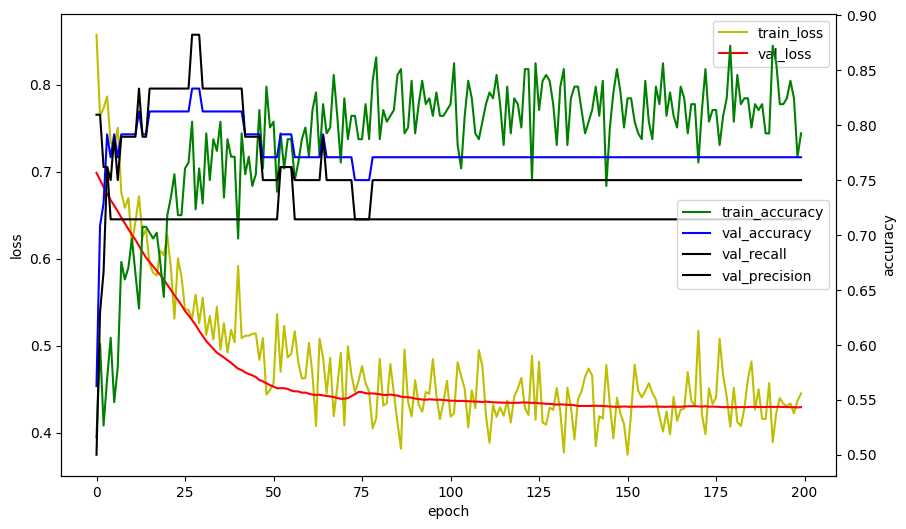

In [83]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall') # recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision') # precision(검정)

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [86]:
# 평가
score = model.evaluate(X_test, y_test, verbose=0)
print(f'model loss : {score[0]}')
print(f'model accuracy : {score[1]*100:.2f}%')
print(f'model recall : {score[2]*100:.2f}%')
print(f'model precision : {score[3]*100:.2f}%')

model loss : 0.38821837306022644
model accuracy : 83.33%
model recall : 85.71%
model precision : 80.00%


In [88]:
# 교차표(혼동행렬)
# 교차표에서의 실제값 : y_test.reshape(-1)
y_hat = (model.predict(X_test, verbose=0) > 0.5).astype(int).reshape(-1) # 예측값을 1차원
                                    # 0과 1의 기준값 0.5를 이동하면 recall과 precision이 바뀜
                                    # 0.5 -> 0.3 recall이 좋아짐(비추)
                                    # 0.5 -> 0.7 precision이 좋아짐(비추)

In [89]:
pd.crosstab(y_test.reshape(-1),
           y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

예측값,0,1
실제값,,
0,26,6
1,4,24


In [90]:
confusion_matrix(y_test, y_hat)

array([[26,  6],
       [ 4, 24]], dtype=int64)

# 4. 모델 사용
- 저장/예측

In [91]:
# 딥러닝 모델 저장시 확장자 : h5, keras
model.save('model/06.h5')
save_model(model, 'model/06.h5')
model1 = load_model('model/06.h5')

In [94]:
data = [[63,1,1,145,233,1,2,150,0,2.3,3,0,6]]
input_data = scaler.transform(data)
(model.predict(input_data) > 0.5).astype(int)

1/1 [==============================] - 0s 29ms/step


array([[0]])

# 분류분석
- 1. 데이터셋 생성 & 전처리
    * X_train, y_train, X_test, y_test -> y_train과 y_test 원핫인코딩
- 2. 모델생성 & 학습과정 설정 & 모델 학습
- 3. 모델평가(학습과정 시각화, 평가, 교차표 argmax이용)
- 4. 모델 사용(저장, 예측)

## 1. 데이터셋 생성 & 전처리
* 0 -> 1 0
* 1 -> 0 1

In [96]:
Y_train = to_categorical(y_train, 2)
Y_test = to_categorical(y_test)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((236, 13), (236, 2), (60, 13), (60, 2))

In [98]:
X_train[0], Y_train[0]

(array([0.33333333, 0.        , 1.        , 0.41509434, 0.25114155,
        0.        , 1.        , 0.61832061, 1.        , 0.03225806,
        0.5       , 0.        , 0.        ]),
 array([1., 0.], dtype=float32))

## 2. 모델생성 & 학습과정 설정 & 학습

In [97]:
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', kernel_regularizer=l2(0.001))) # L2정규화(규제)
model.add(BatchNormalization()) # 출력층의 정규화(최적화)
model.add(Dropout(0.4))               # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(units=2, activation='softmax')) # 분류분석 출력층의 활성화함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_7 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_9 (Dropout)         (None, 32)                0         
                                                                 
 dense_17 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_8 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dropout_10 (Dropout)        (None, 16)                0

In [99]:
model.compile(
             loss="categorical_crossentropy",
          # optimizer=Adam(Learning_rate=0.001),
             optimizer='adam',
             metrics=['accuracy', Recall(name='recall'), Precision(name='precision')]   
)

In [101]:
%%time
hist = model.fit(X_train, Y_train, 
                 epochs=200, 
                 validation_split=0.2, 
                 class_weight=class_weight_dict, 
                 callbacks=[reduce_lr],
                 verbose=1)

Epoch 1/200
6/6 [==============================] - 2s 73ms/step - loss: 1.4694 - accuracy: 0.4309 - recall: 0.4309 - precision: 0.4309 - val_loss: 0.7631 - val_accuracy: 0.5625 - val_recall: 0.5625 - val_precision: 0.5625 - lr: 0.0010
Epoch 2/200
6/6 [==============================] - 0s 9ms/step - loss: 1.1471 - accuracy: 0.4840 - recall: 0.4840 - precision: 0.4840 - val_loss: 0.7566 - val_accuracy: 0.5625 - val_recall: 0.5625 - val_precision: 0.5625 - lr: 0.0010
Epoch 3/200
6/6 [==============================] - 0s 11ms/step - loss: 1.4309 - accuracy: 0.4096 - recall: 0.4096 - precision: 0.4096 - val_loss: 0.7522 - val_accuracy: 0.5625 - val_recall: 0.5625 - val_precision: 0.5625 - lr: 0.0010
Epoch 4/200
6/6 [==============================] - 0s 12ms/step - loss: 1.2989 - accuracy: 0.4628 - recall: 0.4628 - precision: 0.4628 - val_loss: 0.7452 - val_accuracy: 0.5625 - val_recall: 0.5625 - val_precision: 0.5625 - lr: 0.0010
Epoch 5/200
6/6 [==============================] - 0s 12ms/st

Epoch 36/200
6/6 [==============================] - 0s 9ms/step - loss: 0.5860 - accuracy: 0.7447 - recall: 0.7447 - precision: 0.7447 - val_loss: 0.5193 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 37/200
6/6 [==============================] - 0s 9ms/step - loss: 0.6036 - accuracy: 0.6915 - recall: 0.6915 - precision: 0.6915 - val_loss: 0.5147 - val_accuracy: 0.7917 - val_recall: 0.7917 - val_precision: 0.7917 - lr: 0.0010
Epoch 38/200
6/6 [==============================] - 0s 8ms/step - loss: 0.5685 - accuracy: 0.7287 - recall: 0.7287 - precision: 0.7287 - val_loss: 0.5096 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 0.0010
Epoch 39/200
6/6 [==============================] - 0s 8ms/step - loss: 0.5698 - accuracy: 0.7660 - recall: 0.7660 - precision: 0.7660 - val_loss: 0.5047 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 0.0010
Epoch 40/200
6/6 [==============================] - 0s 10ms/

Epoch 71/200
6/6 [==============================] - 0s 10ms/step - loss: 0.5253 - accuracy: 0.7287 - recall: 0.7287 - precision: 0.7287 - val_loss: 0.4493 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 72/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4424 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.4504 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 73/200
6/6 [==============================] - 0s 10ms/step - loss: 0.4950 - accuracy: 0.7553 - recall: 0.7553 - precision: 0.7553 - val_loss: 0.4502 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 74/200
6/6 [==============================] - 0s 9ms/step - loss: 0.5194 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.4508 - val_accuracy: 0.8333 - val_recall: 0.8333 - val_precision: 0.8333 - lr: 0.0010
Epoch 75/200
6/6 [==============================] - 0s 9ms

6/6 [==============================] - 0s 10ms/step - loss: 0.4704 - accuracy: 0.7926 - recall: 0.7926 - precision: 0.7926 - val_loss: 0.4529 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 3.1250e-05
Epoch 106/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4683 - accuracy: 0.7872 - recall: 0.7872 - precision: 0.7872 - val_loss: 0.4536 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 3.1250e-05
Epoch 107/200
6/6 [==============================] - 0s 13ms/step - loss: 0.4292 - accuracy: 0.8191 - recall: 0.8191 - precision: 0.8191 - val_loss: 0.4537 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 3.1250e-05
Epoch 108/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4710 - accuracy: 0.7979 - recall: 0.7979 - precision: 0.7979 - val_loss: 0.4533 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 3.1250e-05
Epoch 109/200
6/6 [==============================] -

6/6 [==============================] - 0s 10ms/step - loss: 0.5098 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4563 - val_accuracy: 0.7500 - val_recall: 0.7500 - val_precision: 0.7500 - lr: 1.9531e-06
Epoch 140/200
6/6 [==============================] - 0s 10ms/step - loss: 0.4757 - accuracy: 0.8032 - recall: 0.8032 - precision: 0.8032 - val_loss: 0.4555 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 141/200
6/6 [==============================] - 0s 9ms/step - loss: 0.4596 - accuracy: 0.7713 - recall: 0.7713 - precision: 0.7713 - val_loss: 0.4557 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 142/200
6/6 [==============================] - 0s 11ms/step - loss: 0.4436 - accuracy: 0.8404 - recall: 0.8404 - precision: 0.8404 - val_loss: 0.4556 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 143/200
6/6 [==============================] 

6/6 [==============================] - 0s 10ms/step - loss: 0.5032 - accuracy: 0.7819 - recall: 0.7819 - precision: 0.7819 - val_loss: 0.4566 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 174/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4728 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4566 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 175/200
6/6 [==============================] - 0s 12ms/step - loss: 0.4985 - accuracy: 0.7979 - recall: 0.7979 - precision: 0.7979 - val_loss: 0.4565 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 176/200
6/6 [==============================] - 0s 10ms/step - loss: 0.4401 - accuracy: 0.8138 - recall: 0.8138 - precision: 0.8138 - val_loss: 0.4558 - val_accuracy: 0.7708 - val_recall: 0.7708 - val_precision: 0.7708 - lr: 1.0000e-06
Epoch 177/200
6/6 [==============================]

## 3. 모델평가(시각화, 평가, 교차표)

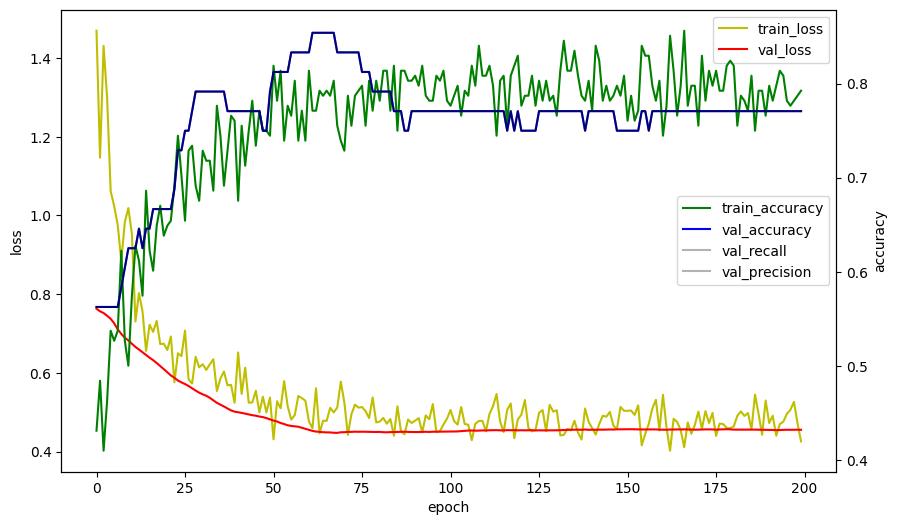

In [106]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall', alpha=0.3) # recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision', alpha=0.3) # precision(검정)

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [109]:
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test, verbose=0)
print('model loss :', loss)
print(f'model accuracy : {accuracy*100:.2f}%')
print(f'model accuracy : {precision*100:.2f}%')
print(f'model accuracy : {recall*100:.2f}%')

model loss : 0.41019490361213684
model accuracy : 85.00%
model accuracy : 85.00%
model accuracy : 85.00%


In [112]:
# 교차표에서의 실제값
Y_test.argmax(axis=1)
y_test.reshape(-1)
y_test.flatten()

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [113]:
# 예측값
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

2/2 [==============================] - 0s 4ms/step


array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [114]:
pd.crosstab(y_test.reshape(-1), y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0,27,5
1,4,24


In [115]:
confusion_matrix(y_test, y_hat)

array([[27,  5],
       [ 4, 24]], dtype=int64)

## 4. 모델 사용
- 저장/예측

In [ ]:
model.save('model/06.h5')
save_model(model, 'model/06.h5')
model2 = load_model('model/06.h5')

In [122]:
data = [[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
                [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]]
input_data = scaler.transform(data)
model.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 20ms/step


array([0, 1], dtype=int64)

In [120]:
X[:2]

array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6],
       [67, 1, 4, 160, 286, 0, 0, 108, 1, 1.5, 2, 3, 3]], dtype=object)